# Perceptron from Scratch: MNIST Study

This notebook separates a faithful 2022 baseline from a measured optimized profile. It also replaces decorative raw-weight grids with **decision evidence**: exact pixel contributions for Rosenblatt and class-logit gradient × input attribution for the MLP.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from sources.binary import RosenblattPerceptron
from sources.data import filter_binary_digits, load_mnist, normalize_images, resize_images_nearest, split_mnist
from sources.explain import binary_decision_evidence, class_average_evidence, input_attributions
from sources.metrics import accuracy, confusion_matrix
from sources.mlp import MultilayerPerceptron
from sources.plotting import (
    plot_attribution_examples,
    plot_binary_decision_evidence,
    plot_binary_history,
    plot_class_evidence,
    plot_confusion,
    plot_layer_weights,
    plot_training_history,
)

## Data: grayscale, not binary

MNIST pixels are **not** thresholded to black and white. `normalize_images` only maps intensities from 0–255 to 0–1, preserving antialiasing and stroke intensity. The final 10,000 samples remain untouched for testing; 10% of the first 60,000 form a deterministic validation set.

In [ ]:
SEED = 42
raw_images, labels = load_mnist(Path("data"))
sample_intensities = np.unique(raw_images[:1_000])

images = normalize_images(raw_images)
train_images, train_labels, validation_images, validation_labels, test_images, test_labels = split_mnist(
    images, labels, validation_fraction=0.1, seed=SEED
)
train_images.shape, validation_images.shape, test_images.shape

Pixel range: 0–255
Unique intensities in first 1,000 images: 256
Thresholding applied: no


((54000, 784), (6000, 784), (10000, 784))

## Binary Rosenblatt perceptron

Canonical zero initialization removes random background weights. Every decision decomposes exactly as `sum(pixel × weight) + bias`. The panels below therefore show what the average 0 and 1 look like and how their pixels push the decision toward class 0 (blue) or class 1 (red).

Binary test accuracy: 99.91%


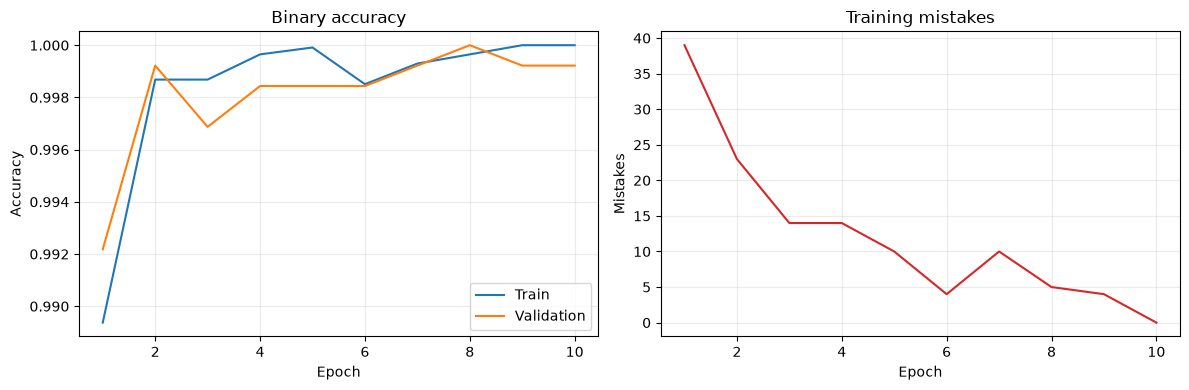

In [3]:
binary_train_x, binary_train_y = filter_binary_digits(train_images, train_labels)
binary_validation_x, binary_validation_y = filter_binary_digits(validation_images, validation_labels)
binary_test_x, binary_test_y = filter_binary_digits(test_images, test_labels)

binary_model = RosenblattPerceptron(
    binary_train_x.shape[1], learning_rate=1e-3, seed=SEED, initialization="zeros"
)
binary_history = binary_model.fit(
    binary_train_x,
    binary_train_y,
    validation_data=(binary_validation_x, binary_validation_y),
    epochs=100,
    early_stopping=True,
    patience=20,
)
binary_predictions = binary_model.predict(binary_test_x)
binary_test_accuracy = accuracy(binary_test_y, binary_predictions)
print(f"Binary test accuracy: {binary_test_accuracy:.2%}")
assert binary_test_accuracy >= 0.98
plot_binary_history(binary_history);

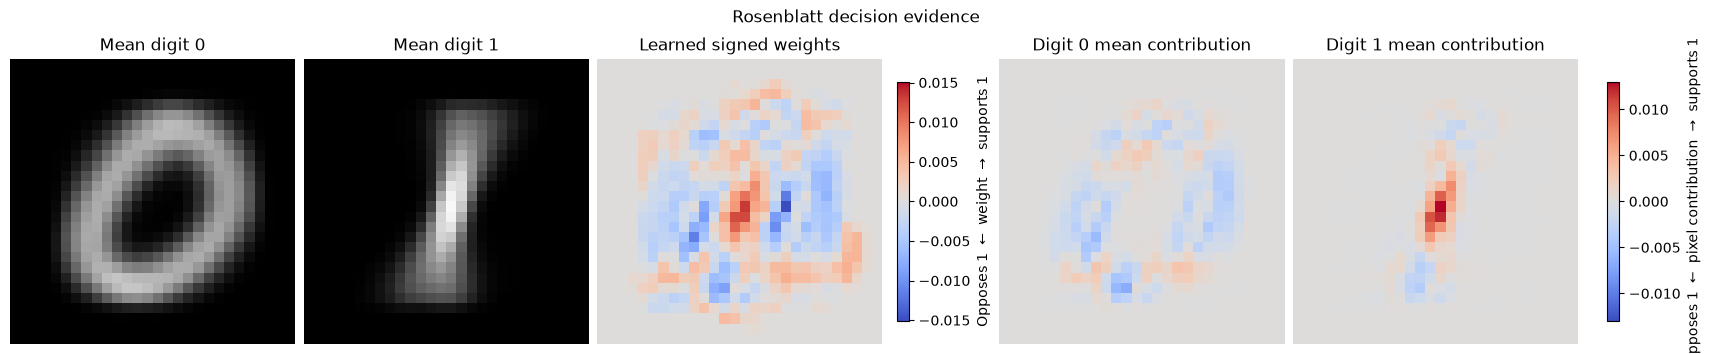

In [4]:
binary_evidence = binary_decision_evidence(binary_model, binary_test_x, binary_test_y)
plot_binary_decision_evidence(binary_evidence);

## Historical baseline

This profile stays close to the 2022 experiment: 14×14 inputs, one 10-neuron hidden layer, full-batch SGD, no decay. It is intentionally retained as a baseline rather than silently replaced by stronger settings.

Historical baseline: 76.37% test accuracy


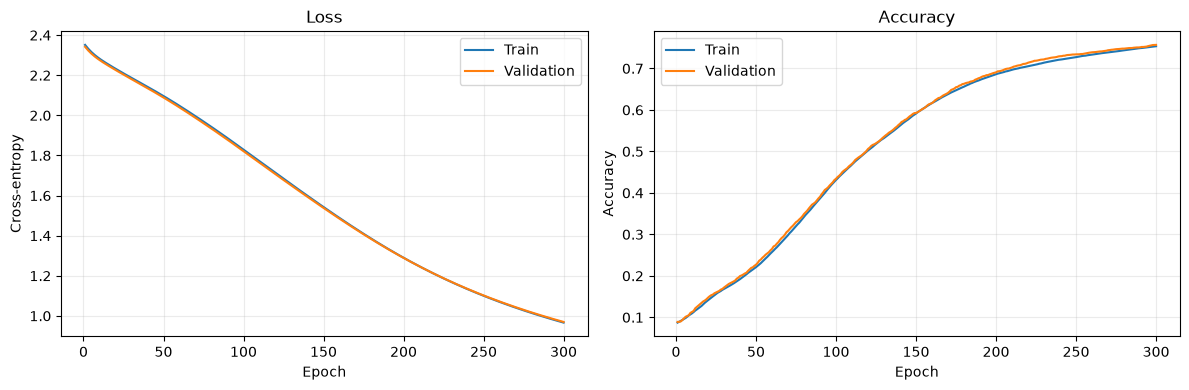

In [5]:
baseline_train_x = resize_images_nearest(train_images, side=14)
baseline_validation_x = resize_images_nearest(validation_images, side=14)
baseline_test_x = resize_images_nearest(test_images, side=14)

baseline_model = MultilayerPerceptron(196, hidden_layers=(10,), n_classes=10, seed=SEED)
started = perf_counter()
baseline_history = baseline_model.fit(
    baseline_train_x,
    train_labels,
    validation_data=(baseline_validation_x, validation_labels),
    epochs=300,
    learning_rate=0.04,
    optimizer="sgd",
    batch_size=None,
    learning_rate_decay=0.0,
    early_stopping=True,
    patience=20,
)
baseline_runtime = perf_counter() - started
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(baseline_test_x, test_labels)
print(f"Historical baseline: {baseline_test_accuracy:.2%} test accuracy")
assert baseline_test_accuracy >= 0.70
plot_training_history(baseline_history);

## Optimized profile

The optimized profile was selected from measured runs, not guessed: full 28×28 grayscale inputs, hidden layers `(64, 32)`, from-scratch momentum, 256-sample mini-batches, and mild inverse-time decay. A 30-epoch benchmark reached **97.34%** test accuracy; extending to 50 epochs did not improve it.

Optimized profile: 97.34% test accuracy


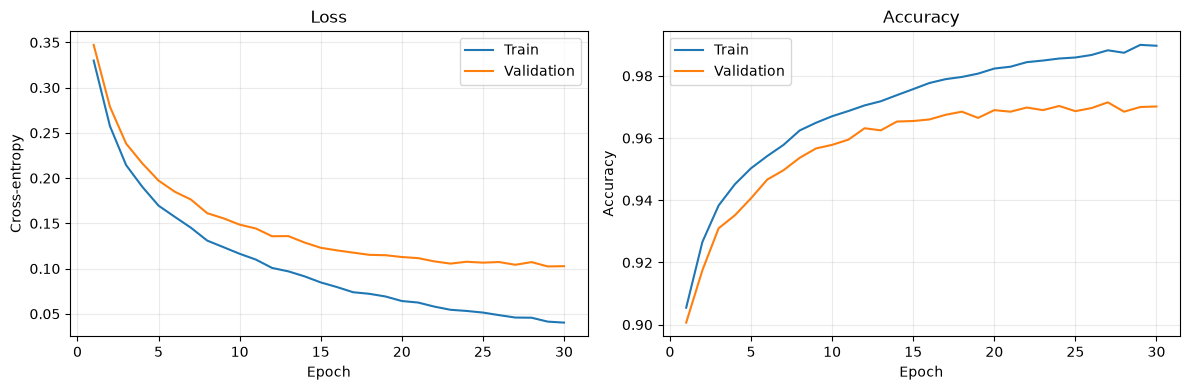

In [6]:
optimized_model = MultilayerPerceptron(
    784, hidden_layers=(64, 32), n_classes=10, seed=SEED
)
started = perf_counter()
optimized_history = optimized_model.fit(
    train_images,
    train_labels,
    validation_data=(validation_images, validation_labels),
    epochs=30,
    learning_rate=0.01,
    optimizer="momentum",
    momentum=0.9,
    batch_size=256,
    learning_rate_decay=0.0005,
    early_stopping=True,
    patience=8,
)
optimized_runtime = perf_counter() - started
optimized_test_loss, optimized_test_accuracy = optimized_model.evaluate(test_images, test_labels)
optimized_predictions = optimized_model.predict(test_images)
print(f"Optimized profile: {optimized_test_accuracy:.2%} test accuracy")
assert optimized_test_accuracy >= 0.97
assert optimized_test_accuracy > baseline_test_accuracy
plot_training_history(optimized_history);

In [ ]:
comparison = f'''| Profile | Resolution | Hidden layers | Optimizer | Batch | Runtime | Validation accuracy | Test loss | Test accuracy |
|---|---:|---:|---|---:|---:|---:|---:|---:|
| Historical | 14×14 | (10,) | SGD | Full | {baseline_runtime:.1f}s | {baseline_history["validation_accuracy"][-1]:.2%} | {baseline_test_loss:.4f} | {baseline_test_accuracy:.2%} |
| Optimized | 28×28 | (64, 32) | Momentum | 256 | {optimized_runtime:.1f}s | {optimized_history["validation_accuracy"][-1]:.2%} | {optimized_test_loss:.4f} | {optimized_test_accuracy:.2%} |'''
display(Markdown(comparison))

| Profile | Resolution | Hidden layers | Optimizer | Batch | Runtime | Validation accuracy | Test loss | Test accuracy |
|---|---:|---:|---|---:|---:|---:|---:|---:|
| Historical | 14×14 | (10,) | SGD | Full | 19.3s | 75.68% | 0.9374 | 76.37% |
| Optimized | 28×28 | (64, 32) | Momentum | 256 | 7.8s | 97.02% | 0.0929 | 97.34% |

## Class-conditioned decision evidence

Raw hidden kernels are not digit templates: ReLU activation patterns and downstream weights determine their meaning. For each correctly classified test digit, the maps below average `input-gradient × input` for the true class logit. Red pixels support that class; blue pixels oppose it.

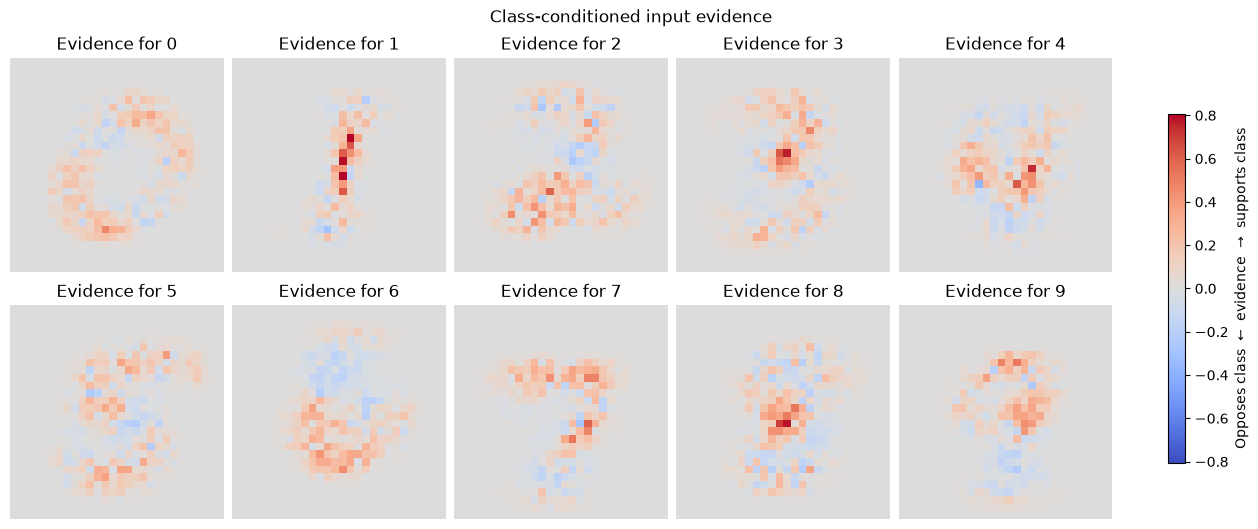

In [ ]:
average_evidence = class_average_evidence(optimized_model, test_images, test_labels, n_classes=10, correctly_classified_only=True)
plot_class_evidence(average_evidence);

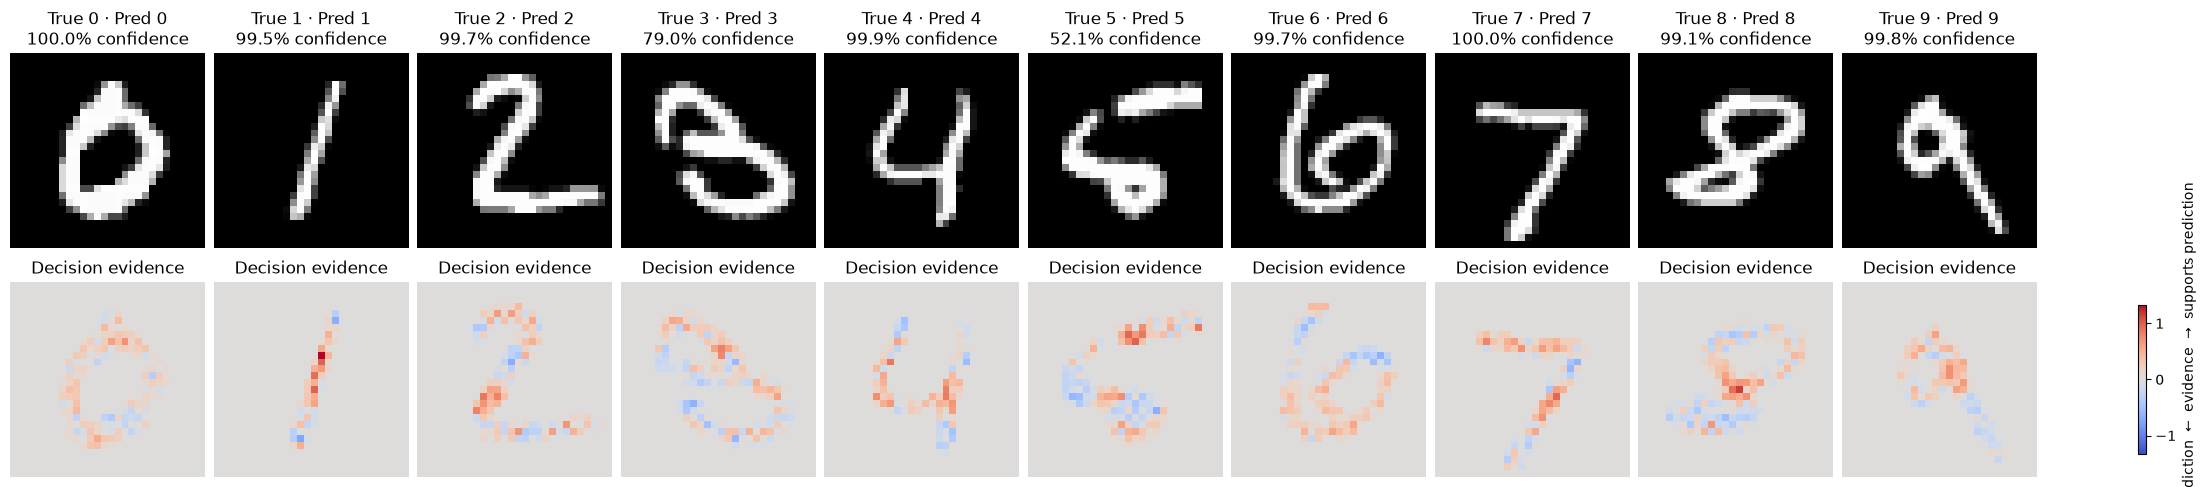

In [9]:
representative_indices = []
for digit in range(10):
    candidates = np.flatnonzero((test_labels == digit) & (optimized_predictions == digit))
    representative_indices.append(candidates[0])

representative_indices = np.asarray(representative_indices)
representative_images = test_images[representative_indices]
representative_labels = test_labels[representative_indices]
representative_predictions = optimized_predictions[representative_indices]
representative_probabilities = optimized_model.forward(representative_images)[1]
representative_evidence = input_attributions(
    optimized_model, representative_images, representative_predictions
)
plot_attribution_examples(
    representative_images,
    representative_evidence,
    representative_labels,
    representative_predictions,
    representative_probabilities,
);

## Architecture views and errors

The following heatmaps show learned **connections**, not image-space explanations. They are kept as secondary architecture views. The confusion matrix shows where the optimized classifier still fails.

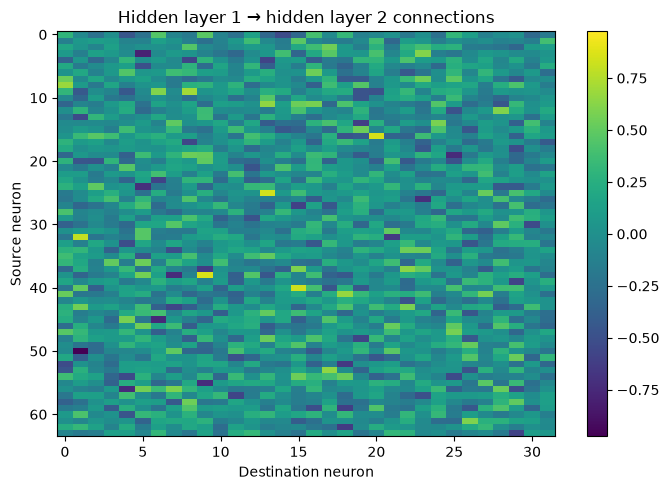

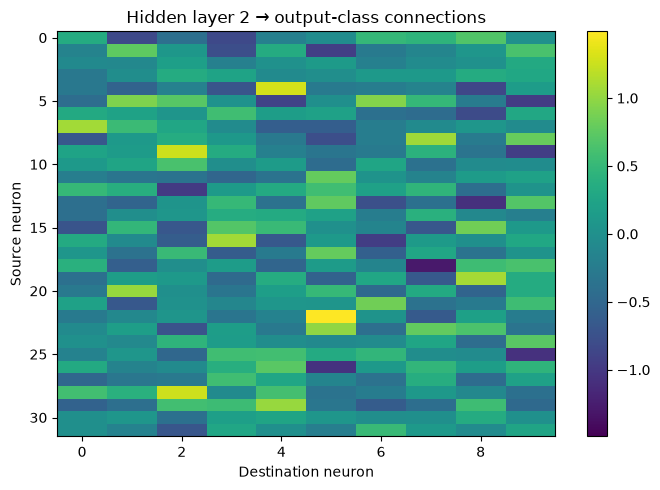

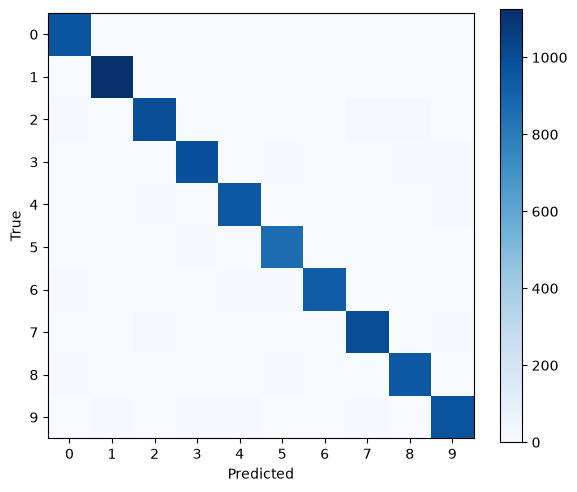

In [12]:
plot_layer_weights(optimized_model.weights[1], "Hidden layer 1 → hidden layer 2 connections");
plot_layer_weights(optimized_model.weights[-1], "Hidden layer 2 → output-class connections");

matrix = confusion_matrix(test_labels, optimized_predictions, n_classes=10)
plot_confusion(matrix, labels=[str(digit) for digit in range(10)]);

## Conclusion

The accuracy increase does not come from “adding a layer” alone. The optimized result combines full-resolution grayscale input, more capacity, shuffled mini-batches, and momentum. The evidence maps answer a different question from raw weights: which visible pixels actually support or oppose each class decision under the trained nonlinear model.